In [1]:

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



sys.path.append("/Users/krisztianivankai/PycharmProjects/Szakdolgozat/")

from models.fuzzy import get_all_fuzzy_membership_values, lag_df, fuzzy_forecast_pipeline
from models.moving_average import forecast_moving_average
from datetime import timedelta

In [2]:
sales_and_stock = pd.read_csv('Szakdoga_adat.csv')

In [3]:
sales_and_stock['date'] = pd.to_datetime(sales_and_stock['date'], format='%Y.%m.%d')

In [4]:
sales_and_stock['day_of_week'] = sales_and_stock['date'].dt.dayofweek + 1
sales_and_stock['month'] = sales_and_stock['date'].dt.month
sales_and_stock['year'] = sales_and_stock['date'].dt.year

In [5]:
sales_and_stock[['sales']].describe()

,sales
count,760.000000
mean,64.298684
std,38.462808
min,1.000000
25%,39.000000
50%,58.000000
75%,80.000000
max,363.000000


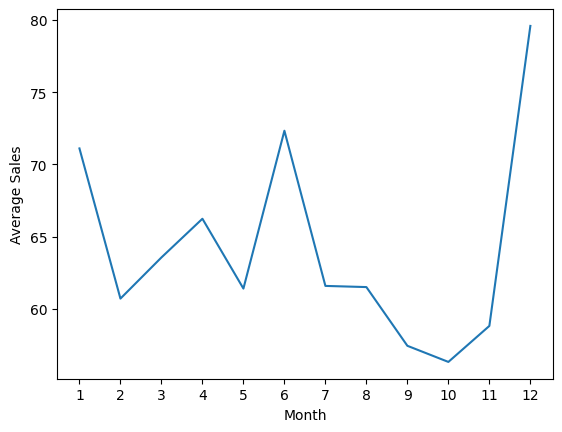

In [6]:
monthly = sales_and_stock.groupby('month')['sales'].mean()
monthly.plot(kind='line')
plt.xlabel('Month')
plt.xticks(range(1, 13))
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

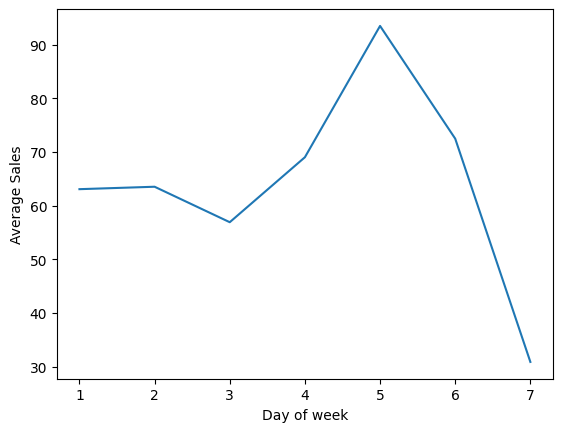

In [7]:
day_of_week = sales_and_stock.groupby('day_of_week')['sales'].mean()
day_of_week.plot(kind='line')
plt.xlabel('Day of week')
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

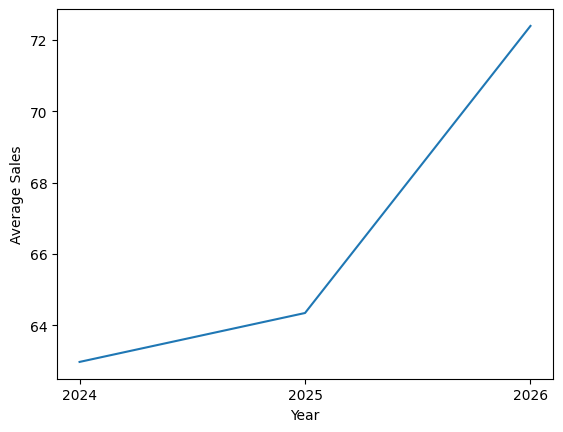

In [8]:
yearly = sales_and_stock.groupby('year')['sales'].mean()
yearly.plot(kind='line')
plt.xlabel('Year')
plt.xticks(range(2024, 2027))
plt.ylabel('Average Sales')
plt.xticks(rotation=0)
plt.show()

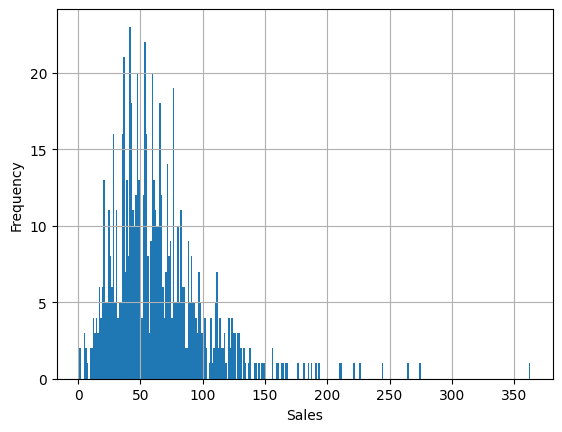

In [9]:
sales_and_stock["sales"].hist(bins=300)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

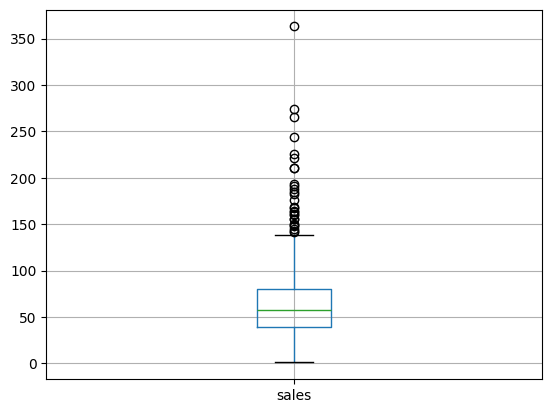

In [10]:
sales_and_stock.boxplot(column="sales")
plt.show()

In [11]:
start_date = sales_and_stock['date'].min()
end_date = sales_and_stock['date'].max()
split_percentage = 0.8
date_range = end_date - start_date
days_to_add_to_split = int(date_range.days * split_percentage)
split_date = start_date + timedelta(days=days_to_add_to_split)

In [12]:
dates = pd.DataFrame({'date': pd.date_range(start=start_date, end=end_date, freq='D')})

In [13]:
demand = dates.merge(sales_and_stock, on='date', how='left')
demand['stock'] = demand['stock'].clip(lower=0).fillna(0)
demand['sales'] = demand['sales'].clip(lower=0)
demand['out_of_stock'] = demand['stock'] <= 0
demand['demand'] = np.where(demand['stock'] > 0, demand['sales'].fillna(0), None)
demand['demand'] = pd.to_numeric(demand['demand'])

In [14]:
demand['demand'] = demand['demand'].interpolate(method='linear')

In [15]:
demand['date'] = pd.to_datetime(demand['date'], format='%Y.%m.%d')

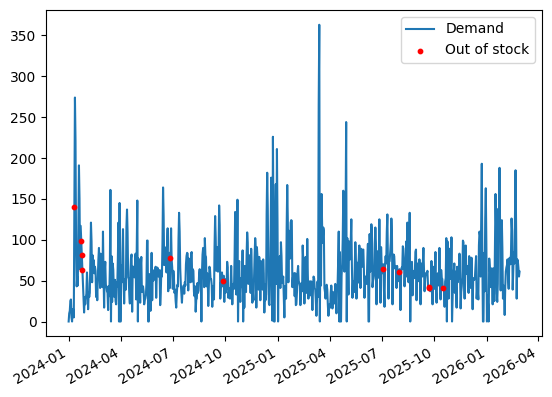

In [16]:
fig, ax = plt.subplots()
ax.plot(demand['date'], demand['demand'], label='Demand')

oos = demand[demand['out_of_stock']]
oos['date'] = pd.to_datetime(oos['date'], format='%Y.%m.%d')
ax.scatter(oos['date'], oos['demand'], color='red', s=10, label='Out of stock', zorder=5)

ax.legend()
fig.autofmt_xdate()
plt.show()

In [17]:
train_data = demand[demand['date'] < split_date].reset_index(drop=True)
test_data = demand[demand['date'] >= split_date].reset_index(drop=True)[['date','demand']]

In [18]:
statistics = train_data[['demand']].describe()

In [19]:
min = statistics.T["min"].to_list()[0]
first_quartile = statistics.T["25%"].to_list()[0]
median = statistics.T["50%"].to_list()[0]
third_quartile = statistics.T["75%"].to_list()[0]
max = statistics.T["max"].to_list()[0]

In [20]:
fuzzy_sets = [
    {
        "name": "VeryLowDemand",
        "type": "shoulder",
        "a": min,
        "b": first_quartile,
        "direction": "left",
    },
    {
        "name": "LowDemand",
        "type": "triangular",
        "a": min,
        "b": first_quartile,
        "c": median,
    },
    {
        "name": "MediumDemand",
        "type": "triangular",
        "a": first_quartile,
        "b": median,
        "c": third_quartile,
    },
    {
        "name": "HighDemand",
        "type": "triangular",
        "a": median,
        "b": third_quartile,
        "c": max
    },
    {
        "name": "VeryHighDemand",
        "type": "shoulder",
        "a": third_quartile,
        "b": max,
        "direction": "right"
    }
]

In [21]:
lagged_train_data = lag_df(train_data, 7, fuzzy_sets)

In [22]:
fuzz_cols = [f'lag_{i}_fuzzy_set' for i in range(1, 8)]
rule_base = (
      lagged_train_data
      .dropna(subset=fuzz_cols + ['demand'])
      [['demand'] + fuzz_cols]
      .groupby(fuzz_cols)
      .mean()
      .reset_index()
  )
rule_base

,lag_1_fuzzy_set,lag_2_fuzzy_set,lag_3_fuzzy_set,lag_4_fuzzy_set,lag_5_fuzzy_set,lag_6_fuzzy_set,lag_7_fuzzy_set,demand
0,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,60.0
1,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,LowDemand,25.0
2,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,MediumDemand,66.0
3,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,VeryLowDemand,28.0
4,HighDemand,HighDemand,HighDemand,HighDemand,HighDemand,LowDemand,HighDemand,74.5
...,...,...,...,...,...,...,...,...
528,VeryLowDemand,VeryLowDemand,LowDemand,LowDemand,LowDemand,LowDemand,LowDemand,21.0
529,VeryLowDemand,VeryLowDemand,LowDemand,LowDemand,VeryLowDemand,VeryLowDemand,VeryLowDemand,15.0
530,VeryLowDemand,VeryLowDemand,VeryLowDemand,LowDemand,LowDemand,VeryLowDemand,VeryLowDemand,15.0
531,VeryLowDemand,VeryLowDemand,VeryLowDemand,VeryLowDemand,LowDemand,LowDemand,VeryLowDemand,5.0


In [23]:
fuzzy_list = []
for i in range(-100, 400):
    value = get_all_fuzzy_membership_values(fuzzy_sets, i)
    value["demand"] = int(i)
    fuzzy_list.append(value)

In [24]:
show_sets = pd.DataFrame(fuzzy_list).melt(
    id_vars="demand",
    var_name="fuzzy_set",
    value_name="membership"
)

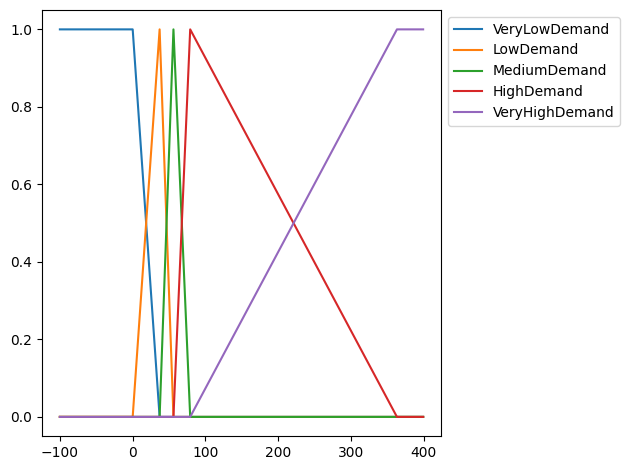

In [25]:
order = ["VeryLowDemand", "LowDemand", "MediumDemand", "HighDemand", "VeryHighDemand"]
for group in order:
    data = show_sets[show_sets["fuzzy_set"] == group]
    plt.plot(data["demand"], data["membership"], label=group)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [26]:
test_data

,date,demand
0,2025-09-22,40.666667
1,2025-09-23,39.000000
2,2025-09-24,37.000000
3,2025-09-25,39.000000
4,2025-09-26,74.000000
...,...,...
154,2026-02-23,76.000000
155,2026-02-24,74.000000
156,2026-02-25,66.000000
157,2026-02-26,55.000000


In [27]:
from evaluate.forecast import forecast_over_horizon
start_date = test_data['date'].min() + timedelta(days=7)

moving_average_forecast = forecast_over_horizon(test_data,start_date,100,forecast_moving_average,[7])

Preidction finished for:2025-09-29 00:00:00
Preidction finished for:2025-09-30 00:00:00
Preidction finished for:2025-10-01 00:00:00
Preidction finished for:2025-10-02 00:00:00
Preidction finished for:2025-10-03 00:00:00
Preidction finished for:2025-10-04 00:00:00
Preidction finished for:2025-10-05 00:00:00
Preidction finished for:2025-10-06 00:00:00
Preidction finished for:2025-10-07 00:00:00
Preidction finished for:2025-10-08 00:00:00
Preidction finished for:2025-10-09 00:00:00
Preidction finished for:2025-10-10 00:00:00
Preidction finished for:2025-10-11 00:00:00
Preidction finished for:2025-10-12 00:00:00
Preidction finished for:2025-10-13 00:00:00
Preidction finished for:2025-10-14 00:00:00
Preidction finished for:2025-10-15 00:00:00
Preidction finished for:2025-10-16 00:00:00
Preidction finished for:2025-10-17 00:00:00
Preidction finished for:2025-10-18 00:00:00
Preidction finished for:2025-10-19 00:00:00
Preidction finished for:2025-10-20 00:00:00
Preidction finished for:2025-10-

In [41]:
fuzzy_model_forecast = forecast_over_horizon(test_data,start_date,40,fuzzy_forecast_pipeline,[fuzzy_sets,7,rule_base])

Zero total strengths
Preidction finished for:2025-09-29 00:00:00
Zero total strengths
Preidction finished for:2025-09-30 00:00:00
Zero total strengths
Preidction finished for:2025-10-01 00:00:00
Zero total strengths
Preidction finished for:2025-10-02 00:00:00
Zero total strengths
Preidction finished for:2025-10-03 00:00:00
Zero total strengths
Preidction finished for:2025-10-04 00:00:00
Zero total strengths
Preidction finished for:2025-10-05 00:00:00
Preidction finished for:2025-10-06 00:00:00
Preidction finished for:2025-10-07 00:00:00
Preidction finished for:2025-10-08 00:00:00
Preidction finished for:2025-10-09 00:00:00
Preidction finished for:2025-10-10 00:00:00
Preidction finished for:2025-10-11 00:00:00
Preidction finished for:2025-10-12 00:00:00
Preidction finished for:2025-10-13 00:00:00
Preidction finished for:2025-10-14 00:00:00
Preidction finished for:2025-10-15 00:00:00
Preidction finished for:2025-10-16 00:00:00
Preidction finished for:2025-10-17 00:00:00
Preidction finish

In [29]:
split_date_plus_7 = split_date + timedelta(days=7)
test_data = test_data[test_data['date']>= split_date_plus_7]

In [30]:
import holidays
hu_holidays = holidays.country_holidays('HU',years=[2024,2025,2026])
holidays_pd = pd.DataFrame([hu_holidays]).melt()


In [31]:
holidays_pd = holidays_pd[~holidays_pd['value'].str.contains('Pihenőnap')]

In [32]:
holidays_pd['holiday_demand'] = 0
holidays_pd['date'] = pd.to_datetime(holidays_pd['variable'])

In [33]:
fuzzy_model_forecast_analyses = fuzzy_model_forecast.merge(holidays_pd,how='left',left_on='date',right_on='date')


In [34]:
fuzzy_model_forecast_analyses['prediction'] = fuzzy_model_forecast_analyses['holiday_demand'].combine_first(fuzzy_model_forecast_analyses['prediction'])
fuzzy_model_forecast_analyses.merge(test_data, how='left', left_on='date', right_on='date')

,date,prediction,variable,value,holiday_demand,demand
0,2025-09-29,36.608362,NaN,NaN,NaN,67.0
1,2025-09-30,38.805452,NaN,NaN,NaN,45.0
2,2025-10-01,34.916978,NaN,NaN,NaN,40.0
3,2025-10-02,36.651742,NaN,NaN,NaN,53.0
4,2025-10-03,37.757948,NaN,NaN,NaN,85.0
5,2025-10-04,39.531233,NaN,NaN,NaN,37.0
6,2025-10-05,39.531233,NaN,NaN,NaN,23.0
7,2025-10-06,40.311777,NaN,NaN,NaN,57.0
8,2025-10-07,40.311777,NaN,NaN,NaN,59.0
9,2025-10-08,40.333956,NaN,NaN,NaN,48.0


In [35]:
from evaluate.evaluate_model import get_model_score
fuzzy_model_forecast['forecast'] = fuzzy_model_forecast['prediction']
fuzzy_score = get_model_score(test_data, fuzzy_model_forecast)

In [36]:
moving_average_forecast['forecast'] = moving_average_forecast['prediction']
moving_average_score = get_model_score(test_data, moving_average_forecast)

In [37]:
moving_average_forecast=moving_average_forecast.merge(holidays_pd,how='left',on='date')
moving_average_forecast['prediction'] = moving_average_forecast['holiday_demand'].combine_first(moving_average_forecast['prediction'])
moving_average_forecast.merge(test_data, how='left', left_on='date', right_on='date')

,date,prediction,forecast,variable,value,holiday_demand,demand
0,2025-09-29,43.380952,43.380952,NaN,NaN,NaN,67.0
1,2025-09-30,47.142857,47.142857,NaN,NaN,NaN,45.0
2,2025-10-01,48.000000,48.000000,NaN,NaN,NaN,40.0
3,2025-10-02,48.428571,48.428571,NaN,NaN,NaN,53.0
4,2025-10-03,50.428571,50.428571,NaN,NaN,NaN,85.0
...,...,...,...,...,...,...,...
95,2026-01-02,72.000000,72.000000,NaN,NaN,NaN,32.0
96,2026-01-03,76.571429,76.571429,NaN,NaN,NaN,21.0
97,2026-01-04,67.571429,67.571429,NaN,NaN,NaN,0.0
98,2026-01-05,62.285714,62.285714,NaN,NaN,NaN,77.0


In [38]:
fuzzy_score

,mae,bias,score
0,15.099004,82.503613,97.602618


In [39]:
moving_average_score

,mae,bias,score
0,24.940476,-4.238095,29.178571
